# 2b

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 200
plt.rc('font', family='sans-serif')
plt.rc('axes', labelsize=14)
plt.rc('axes', labelweight='bold')
plt.rc('axes', titlesize=16)
plt.rc('axes', titleweight='bold')
plt.rc('axes', linewidth=2)

In [3]:
sig = np.sqrt(np.log(1/0.2)/1.3)
print(sig)

1.112667588910024


In [27]:
# masses = np.linspace(0.01,100, 10000)
masses = np.logspace(-2, 2, 10000)


def chabrier(m, sigma=sig, m_b=1.0, m_c=0.2, b=2.3):
    lognormal_at_break = m_b**(-1) * np.exp(-(np.log(m_b / m_c))**2 / (2 * sigma**2))
    powerlaw_at_break  = m_b**(-b)
    
    A = lognormal_at_break / powerlaw_at_break

    if m <= m_b:
        n = m**(-1) * np.exp(-(np.log(m / m_c))**2 / (2 * sigma**2))
    else:
        n = A * m**(-b)
    return n

In [28]:
imf = np.array([chabrier(m, sig) for m in masses])

In [29]:
peak = np.max(imf)
norm_imf = imf / peak

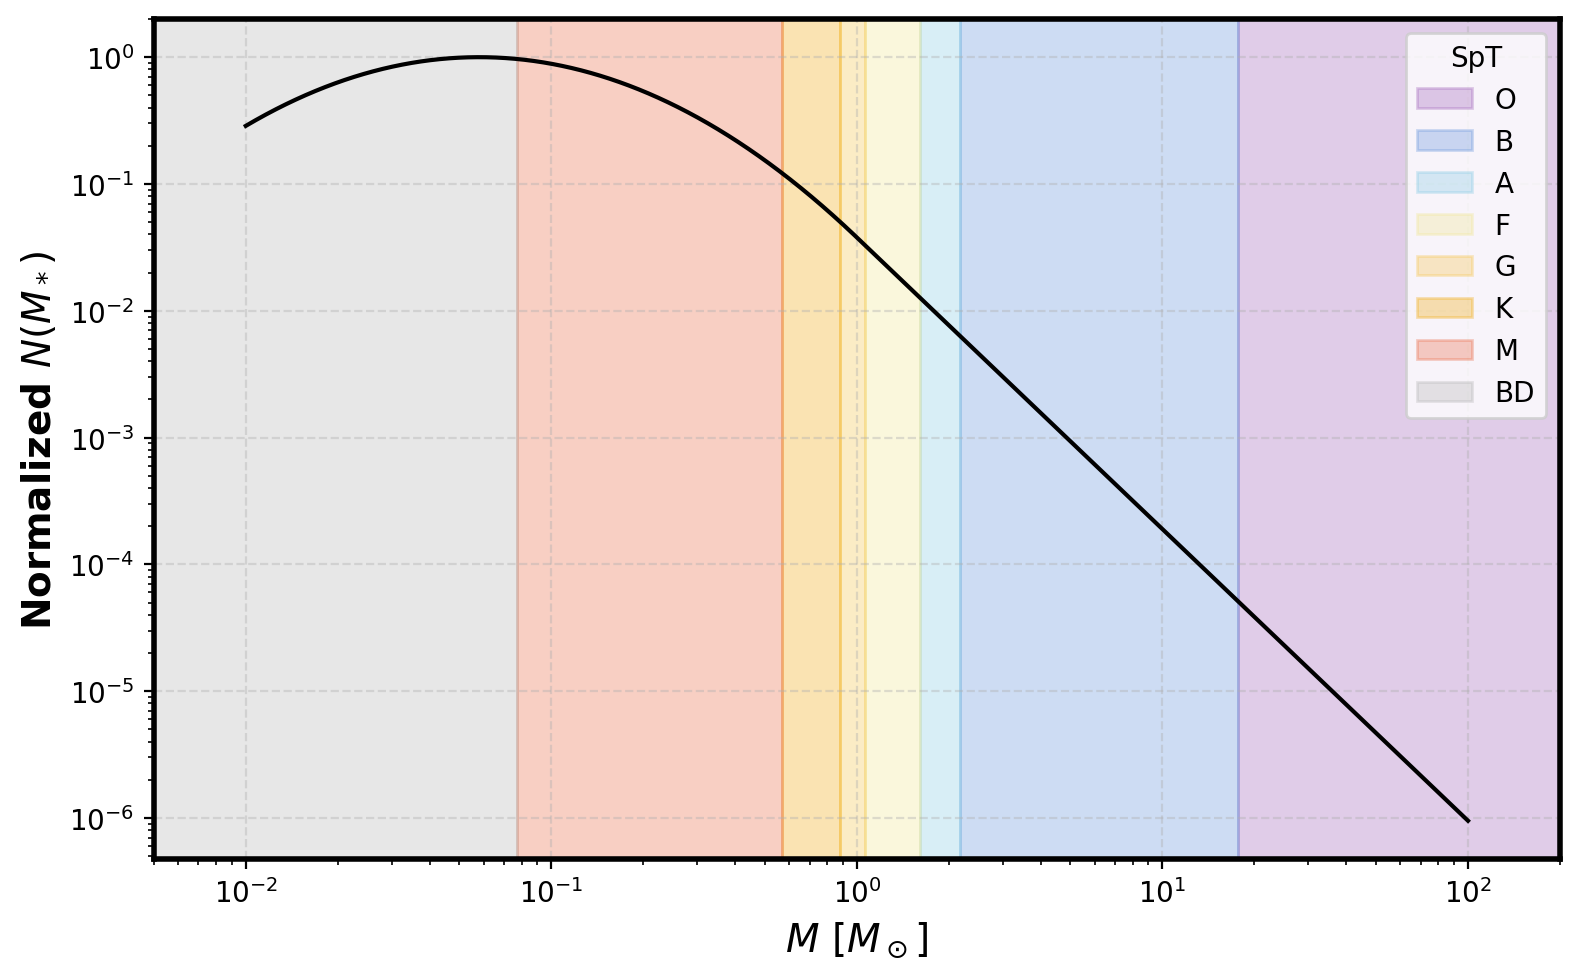

In [30]:
spts = np.array([17.7, 2.18, 1.61, 1.06, 0.88, 0.57, 0.077])

spectral_types = ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'BD']
colors = ['#9b59b6', '#5b8dd9', '#7ec8e3', '#f0e68c', '#f5c242', '#f0a500', '#e8623a', '#b0b0b0']

x_max = masses.max() * 10
boundaries = np.concatenate([[x_max], spts, [0]])

for i in range(len(spectral_types)):
    x_right = boundaries[i]
    x_left  = boundaries[i + 1]
    plt.axvspan(x_left, x_right, alpha=0.3, color=colors[i], label=spectral_types[i])

plt.plot(masses, norm_imf, 'k')
plt.yscale('log')
plt.xscale('log')
plt.grid(linestyle='--', alpha=0.4)
plt.ylabel('Normalized $N(M_*)$')
plt.xlabel(r'$M~[M_\odot]$')
plt.legend(title='SpT', loc='upper right')
plt.xlim(0.005,200)
plt.tight_layout()
plt.savefig('hw5_2a.png')
plt.show()

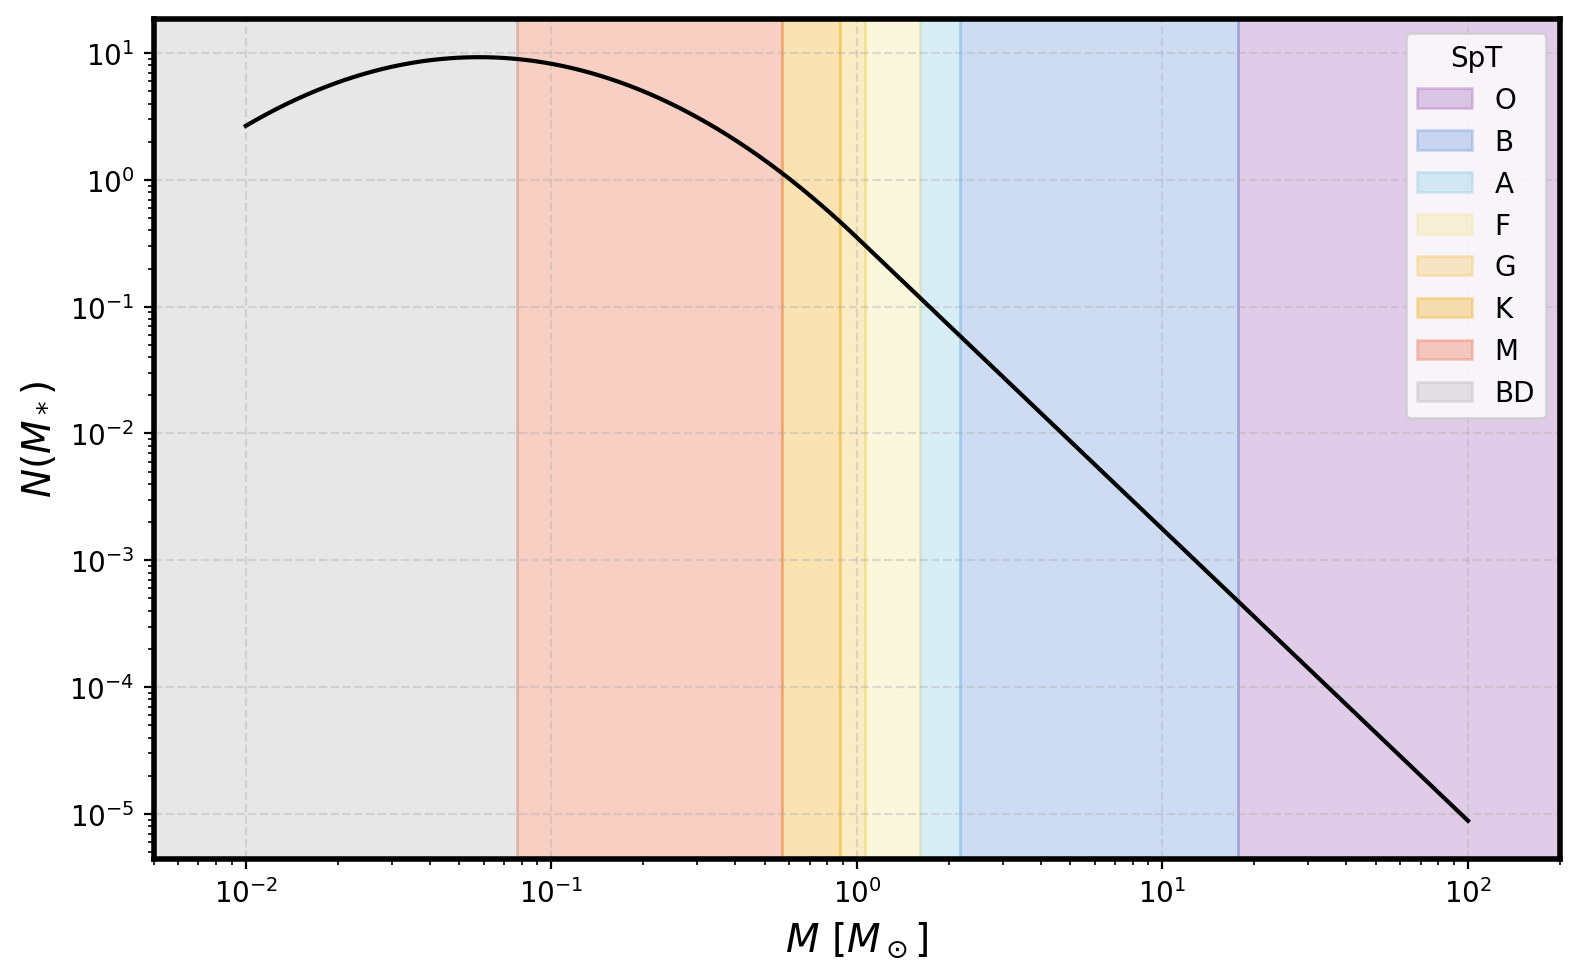

In [31]:
for i in range(len(spectral_types)):
    x_right = boundaries[i]
    x_left  = boundaries[i + 1]
    plt.axvspan(x_left, x_right, alpha=0.3, color=colors[i], label=spectral_types[i])

plt.plot(masses, imf, 'k')
plt.yscale('log')
plt.xscale('log')
plt.grid(linestyle='--', alpha=0.4)
plt.ylabel('$N(M_*)$')
plt.xlabel(r'$M~[M_\odot]$')
plt.legend(title='SpT', loc='upper right')
plt.xlim(0.005,200)
plt.tight_layout()
plt.show()

In [9]:
print(masses[np.argmax(norm_imf)])

0.05800526653769882


In [10]:
from scipy.integrate import quad

In [11]:
def CDF(m, imf, m_min, m_max):
    top, _ = quad(imf, m_max, m)
    bot, _ = quad(imf, m_max, m_min)
    return top/bot

In [12]:
cdf = np.array([CDF(m, chabrier, 0.01, 150) for m in masses])

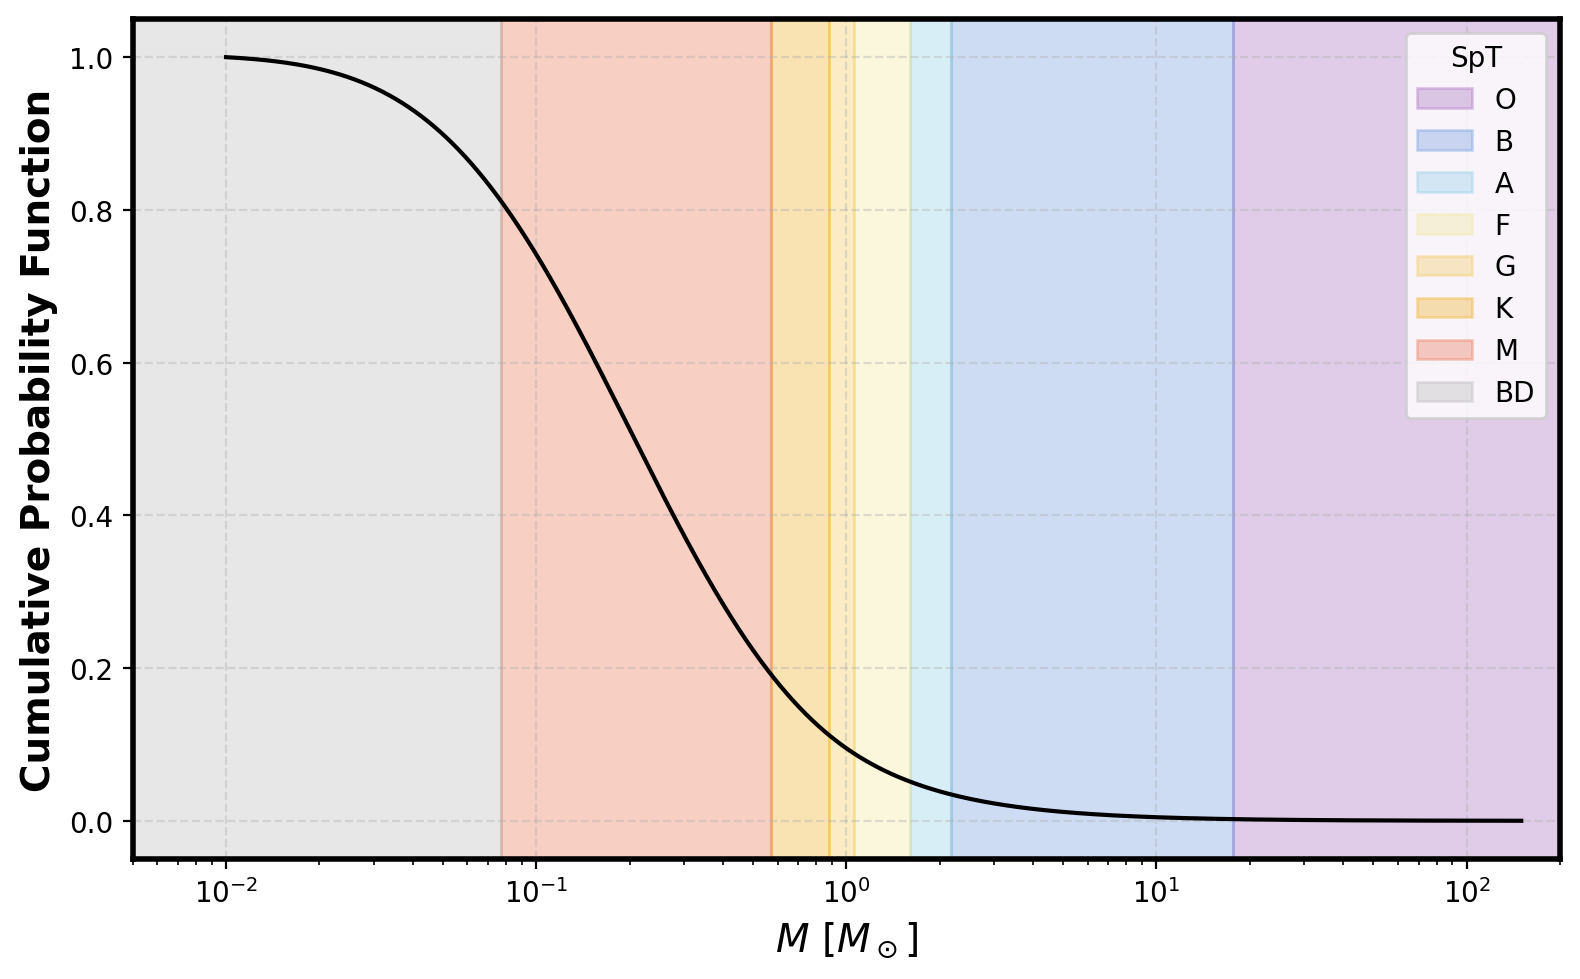

In [13]:
spts = np.array([17.7, 2.18, 1.61, 1.06, 0.88, 0.57, 0.077])

spectral_types = ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'BD']
colors = ['#9b59b6', '#5b8dd9', '#7ec8e3', '#f0e68c', '#f5c242', '#f0a500', '#e8623a', '#b0b0b0']

x_max = masses.max() * 10
boundaries = np.concatenate([[x_max], spts, [0]])

for i in range(len(spectral_types)):
    x_right = boundaries[i]
    x_left  = boundaries[i + 1]
    plt.axvspan(x_left, x_right, alpha=0.3, color=colors[i], label=spectral_types[i])

plt.plot(masses, cdf, 'k')
plt.xscale('log')
plt.grid(linestyle='--', alpha=0.4)
# plt.ylabel('Normalized $N(M_*)$')
# plt.xlabel(r'$M~[M_\odot]$')
plt.legend(title='SpT', loc='upper right')
plt.xlim(0.005,200)
plt.ylabel('Cumulative Probability Function')
plt.xlabel(r'$M~[M_\odot]$')
plt.tight_layout()
plt.savefig('hw4_2c.png')
plt.show()

### Spectral Type Fractions

In [14]:
total_n = len(masses)

In [15]:
BD = np.where(masses < 0.077)
O = np.where((masses < 150) & (masses>17.7))
B = np.where((masses < 17.7) & (masses>2.18))
A = np.where((masses < 2.18) & (masses>1.61))
F = np.where((masses < 1.61) & (masses>1.06))
G = np.where((masses < 1.06) & (masses>0.88))
K = np.where((masses < 0.88) & (masses>0.57))
M = np.where((masses < 0.57) & (masses>0.077))

type_masses = [O, B, A, F, G, K, M , BD]

fractions = []
for i in range(len(type_masses)):
    fractions.append((np.max(cdf[type_masses[i]]) - np.min(cdf[type_masses[i]])))

np.sum(fractions)

np.float64(0.9991889066712332)

#### Mass fractions by SpT

In [16]:
def chabrier_mass_weighted(m, sigma=sig, m_b=1.0, m_c=0.2, b=2.3):
    return m * chabrier(m, sigma, m_b, m_c, b)

def mass_CDF(m, m_min=0.01, m_max=150):
    top, _ = quad(chabrier_mass_weighted, m_max, m)
    bot, _ = quad(chabrier_mass_weighted, m_max, m_min)
    return top / bot

mass_cdf = np.array([mass_CDF(m) for m in masses])

mass_fractions = []
for i in range(len(type_masses)):
    mass_fractions.append(
        np.max(mass_cdf[type_masses[i]]) - np.min(mass_cdf[type_masses[i]])
    )

print(np.sum(mass_fractions))

0.9988103311557834


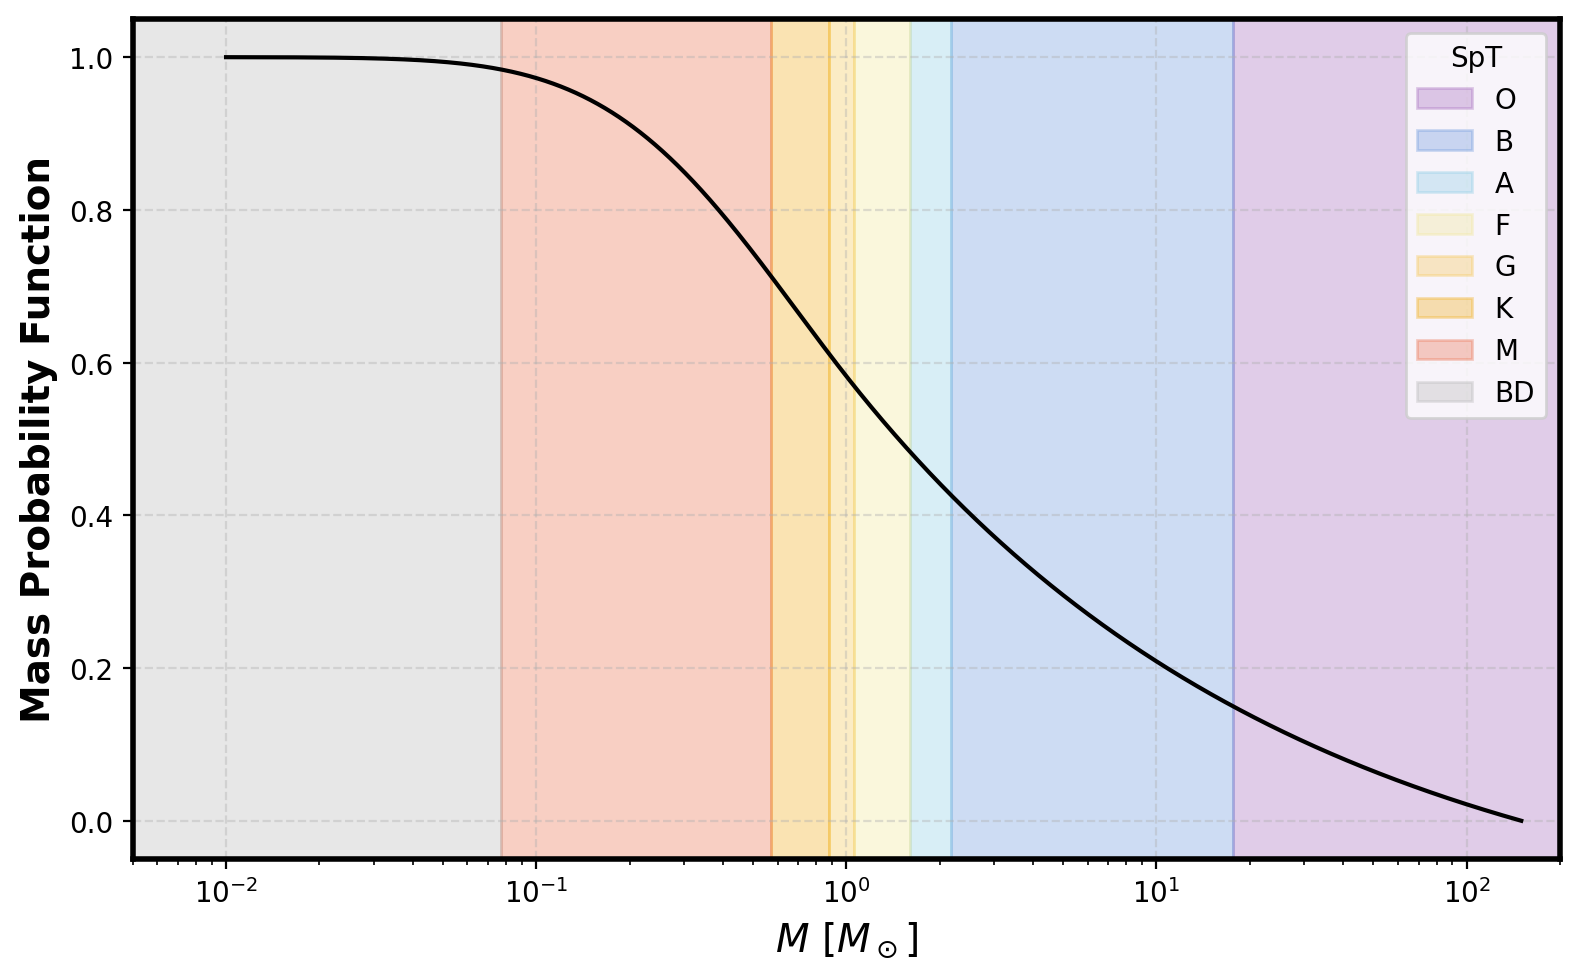

In [17]:
for i in range(len(spectral_types)):
    x_right = boundaries[i]
    x_left  = boundaries[i + 1]
    plt.axvspan(x_left, x_right, alpha=0.3, color=colors[i], label=spectral_types[i])

plt.plot(masses, mass_cdf, 'k')
plt.xscale('log')
plt.grid(linestyle='--', alpha=0.4)

plt.legend(title='SpT', loc='upper right')
plt.xlim(0.005,200)
plt.ylabel('Mass Probability Function')
plt.xlabel(r'$M~[M_\odot]$')
plt.tight_layout()

plt.show()

### Luminosity fractions by SpT

In [26]:
def chabrier_lum_weighted(m, sigma=sig, m_b=1.0, m_c=0.2, b=2.3):
    return m**(3.5) * chabrier(m, sigma, m_b, m_c, b)

def lum_CDF(m, m_min=0.01, m_max=150):
    top, _ = quad(chabrier_lum_weighted, m_max, m)
    bot, _ = quad(chabrier_lum_weighted, m_max, m_min)
    return top / bot

lum_cdf = np.array([lum_CDF(m) for m in masses])

lum_fractions = []
for i in range(len(type_masses)):
    lum_fractions.append(
        np.max(lum_cdf[type_masses[i]]) - np.min(lum_cdf[type_masses[i]])
    )

np.sum(lum_fractions)

np.float64(0.997913854741197)

In [19]:
print(fractions)

[np.float64(0.0021262284152806957), np.float64(0.03220584403991349), np.float64(0.01665947130248939), np.float64(0.03680703716350401), np.float64(0.02401833250021021), np.float64(0.07995847549771748), np.float64(0.6192175305051485), np.float64(0.1881959872469693)]


In [20]:
print(mass_fractions)

[np.float64(0.149588112224693), np.float64(0.2762478402308914), np.float64(0.05638615014704351), np.float64(0.08639100460407756), np.float64(0.0420715919372282), np.float64(0.10210896259065794), np.float64(0.26992635848204005), np.float64(0.01609031093915181)]


In [21]:
print(lum_fractions)

[np.float64(0.9888480184638585), np.float64(0.008975980136475159), np.float64(4.40763921965015e-05), np.float64(2.7854456606801747e-05), np.float64(6.209422933611819e-06), np.float64(7.2178369919795315e-06), np.float64(3.1475881180353937e-06), np.float64(1.3504440163902842e-06)]


In [22]:
m_min, m_max = 0.01, 150

numerator,   _ = quad(lambda m: m * chabrier(m), m_min, m_max)
denominator, _ = quad(lambda m: chabrier(m),     m_min, m_max)

mean_mass = numerator / denominator  # in solar masses
print(f"Mean stellar mass: {mean_mass:.3f} M_sun")

M_total = 1e10  # solar masses
N_stars = M_total / mean_mass
print(f"Number of stars: {N_stars:.3e}")

Mean stellar mass: 0.550 M_sun
Number of stars: 1.818e+10


In [23]:
M_total = 1e10

# Stars formed in WD progenitor range
n_wd_range, _ = quad(lambda m: chabrier(m), 1.0, 8.0)

# Total mass normalization (same denominator as before)
mass_norm, _  = quad(lambda m: m * chabrier(m), m_min, m_max)

N_wd = M_total * n_wd_range / mass_norm
print(f"Number of WDs: {N_wd:.3e}")

Number of WDs: 1.612e+09


In [24]:
M_total = 1e10

# Stars formed in WD progenitor range
n_ns_range, _ = quad(lambda m: chabrier(m), 8.0, 20.0)

# Total mass normalization (same denominator as before)
mass_norm, _  = quad(lambda m: m * chabrier(m), m_min, m_max)

N_ns = M_total * n_ns_range / mass_norm
print(f"Number of NSs: {N_ns:.3e}")

Number of NSs: 8.058e+07


In [25]:
M_total = 1e10

# Stars formed in WD progenitor range
n_bh_range, _ = quad(lambda m: chabrier(m), 20.0, 100.0)

# Total mass normalization (same denominator as before)
mass_norm, _  = quad(lambda m: m * chabrier(m), m_min, m_max)

N_bh = M_total * n_bh_range / mass_norm
print(f"Number of BHs: {N_bh:.3e}")

Number of BHs: 3.083e+07
